## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

TensorFlow version: 2.16.1
NumPy version: 1.26.4
Pandas version: 2.2.2


## 2. Load and Explore Dataset

In [6]:
# Load cattle sensor training data
df = pd.read_csv('dl_service/data/cattle_training_data.csv', parse_dates=['timestamp'])
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nCattle IDs: {df['cattle_id'].unique()}")
print(f"\nDataset Info:")
df.info()

Dataset shape: (21600, 11)

Columns: ['timestamp', 'cattle_id', 'temperature', 'heartRate', 'humidity', 'distance', 'hour', 'day_of_week', 'is_anomaly', 'anomaly_type', 'heart_rate']

Cattle IDs: ['COW_001' 'COW_002' 'COW_003' 'COW_004' 'COW_005']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     21600 non-null  datetime64[ns]
 1   cattle_id     21600 non-null  object        
 2   temperature   21600 non-null  float64       
 3   heartRate     21600 non-null  float64       
 4   humidity      21600 non-null  float64       
 5   distance      21600 non-null  float64       
 6   hour          21600 non-null  int64         
 7   day_of_week   21600 non-null  int64         
 8   is_anomaly    21600 non-null  int64         
 9   anomaly_type  21600 non-null  object        
 10  heart_rate    147 non-n

In [8]:
# Statistical summary
df[['temperature', 'humidity', 'heartRate', 'distance']].describe()

,temperature,humidity,heartRate,distance
count,21600.000000,21600.000000,21600.000000,21600.000000
mean,38.857059,65.169472,60.227472,24.288931
std,0.484450,6.754728,11.521406,28.131365
min,37.920000,46.900000,20.200000,0.000000
25%,38.540000,59.800000,51.900000,4.700000
50%,38.810000,65.100000,59.900000,13.300000
75%,39.080000,70.300000,68.000000,33.100000
max,42.500000,99.700000,129.600000,120.000000


In [10]:
# Check for missing values
print("Missing values:\n")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df)}")
print(f"Anomaly distribution:\n{df['is_anomaly'].value_counts()}")

Missing values:

timestamp           0
cattle_id           0
temperature         0
heartRate           0
humidity            0
distance            0
hour                0
day_of_week         0
is_anomaly          0
anomaly_type        0
heart_rate      21453
dtype: int64

Total rows: 21600
Anomaly distribution:
is_anomaly
0    20955
1      645
Name: count, dtype: int64


## 3. Data Visualization

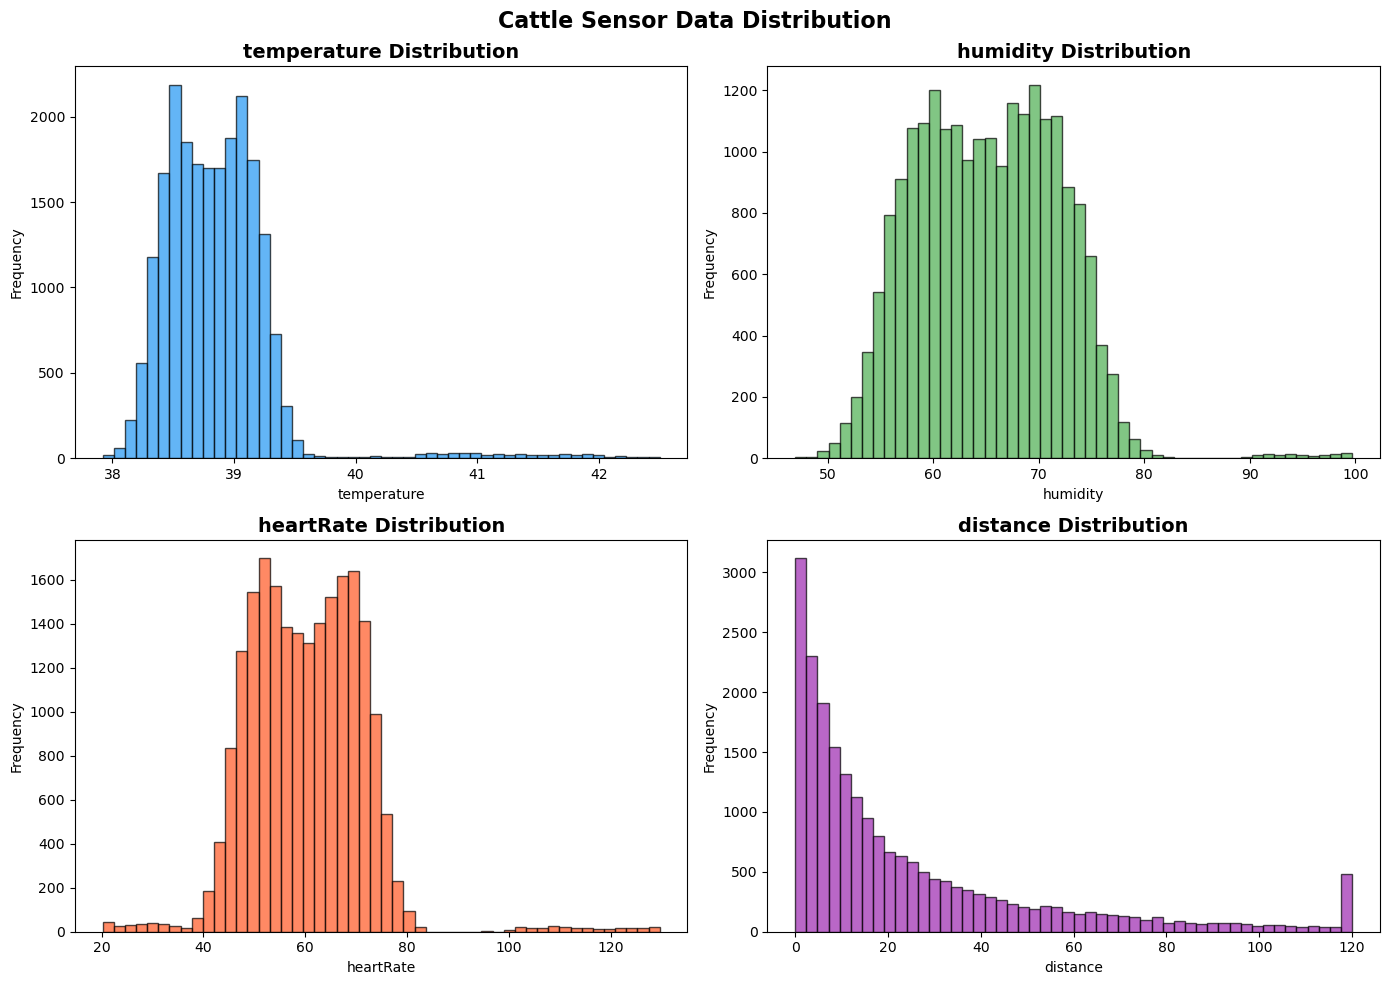

In [13]:
# Sensor data distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features_plot = ['temperature', 'humidity', 'heartRate', 'distance']
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0']

for i, (feat, color) in enumerate(zip(features_plot, colors)):
    ax = axes[i//2][i%2]
    ax.hist(df[feat].dropna(), bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.set_title(f'{feat} Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')

plt.suptitle('Cattle Sensor Data Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sensor_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

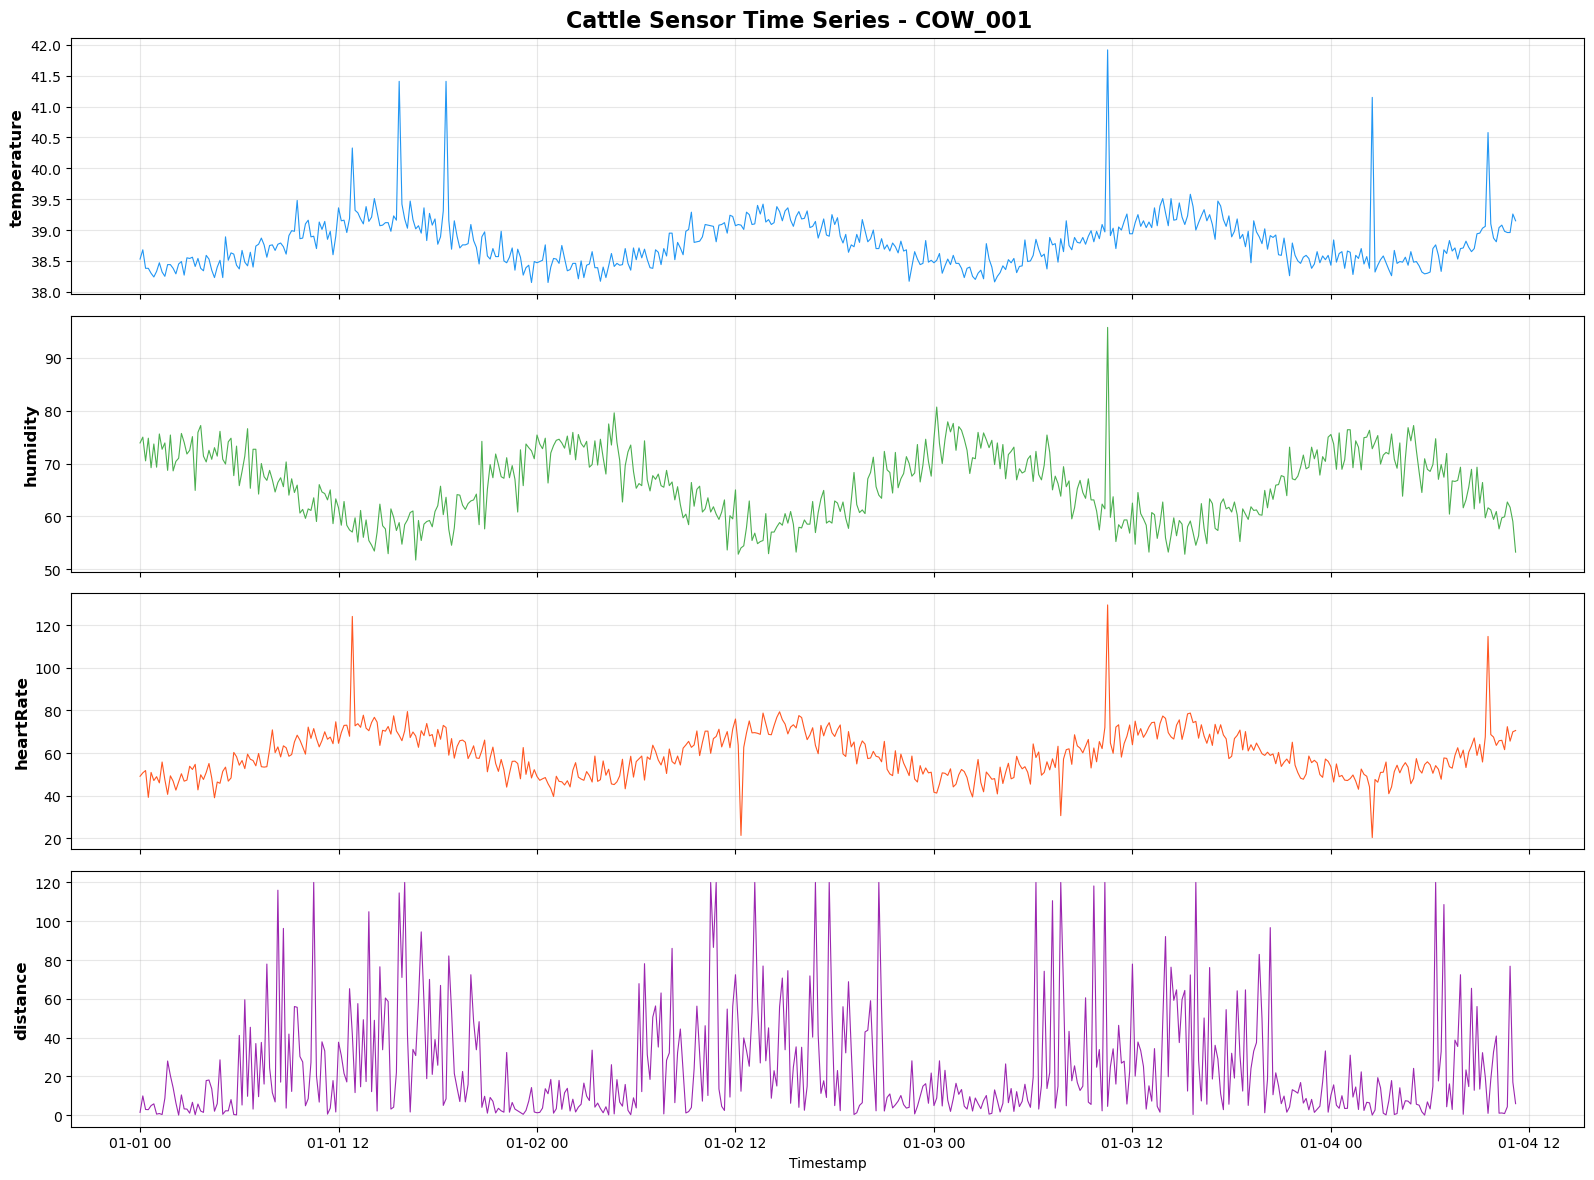

In [15]:
# Time series visualization per cattle
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
cow = df[df['cattle_id'] == 'COW_001'].head(500)

for i, feat in enumerate(features_plot):
    axes[i].plot(cow['timestamp'], cow[feat], color=colors[i], linewidth=0.8)
    axes[i].set_ylabel(feat, fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Cattle Sensor Time Series - COW_001', fontsize=16, fontweight='bold')
plt.xlabel('Timestamp')
plt.tight_layout()
plt.savefig('time_series_cow001.png', dpi=150, bbox_inches='tight')
plt.show()

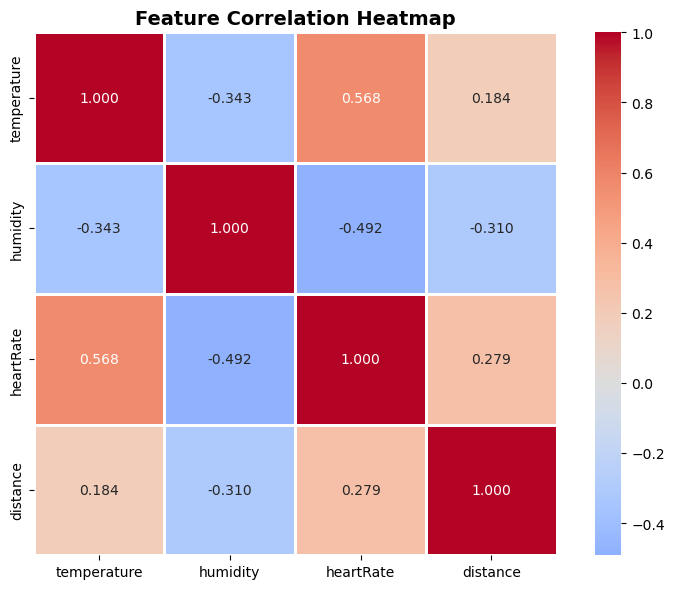

In [17]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[['temperature', 'humidity', 'heartRate', 'distance']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            linewidths=1, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [20]:
# Define features and parameters
FEATURES = ['temperature', 'humidity', 'heartRate', 'distance', 'hour', 'day_of_week']
SEQUENCE_LENGTH = 30
N_FEATURES = len(FEATURES)

print(f"Features: {FEATURES}")
print(f"Sequence Length: {SEQUENCE_LENGTH}")
print(f"Number of Features: {N_FEATURES}")

Features: ['temperature', 'humidity', 'heartRate', 'distance', 'hour', 'day_of_week']
Sequence Length: 30
Number of Features: 6


In [22]:
# Filter normal data only for training
df_normal = df[df['is_anomaly'] == 0].copy()
df_normal = df_normal.dropna(subset=FEATURES)
df_normal = df_normal.sort_values(['cattle_id', 'timestamp']).reset_index(drop=True)

print(f"Normal samples for training: {len(df_normal)}")
print(f"Anomaly samples removed: {len(df) - len(df_normal)}")

Normal samples for training: 20955
Anomaly samples removed: 645


In [24]:
# MinMaxScaler normalization
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_normal[FEATURES].values)

print(f"Scaled data shape: {scaled_data.shape}")
print(f"Min values after scaling: {scaled_data.min(axis=0)}")
print(f"Max values after scaling: {scaled_data.max(axis=0)}")

Scaled data shape: (20955, 6)
Min values after scaling: [0. 0. 0. 0. 0. 0.]
Max values after scaling: [1. 1. 1. 1. 1. 1.]


In [26]:
# Create sequences (sliding window approach)
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences, dtype=np.float32)

all_sequences = create_sequences(scaled_data, SEQUENCE_LENGTH)
print(f"Total sequences created: {all_sequences.shape}")
print(f"Each sequence shape: ({SEQUENCE_LENGTH}, {N_FEATURES})")

Total sequences created: (20926, 30, 6)
Each sequence shape: (30, 6)


## 5. Build LSTM Autoencoder Architecture

### 5.1 Model Architecture

In [30]:
def build_autoencoder(sequence_length, n_features, dropout_rate=0.2):
    model = models.Sequential([
        # Encoder
        layers.Input(shape=(sequence_length, n_features)),
        layers.LSTM(128, activation='tanh', return_sequences=True),
        layers.Dropout(dropout_rate),
        layers.LSTM(64, activation='tanh', return_sequences=False),
        layers.Dropout(dropout_rate),
        
        # Bottleneck
        layers.RepeatVector(sequence_length),
        
        # Decoder
        layers.LSTM(64, activation='tanh', return_sequences=True),
        layers.Dropout(dropout_rate),
        layers.LSTM(128, activation='tanh', return_sequences=True),
        layers.TimeDistributed(layers.Dense(n_features)),
    ])
    
    model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mse')
    return model

# Build and display model
model = build_autoencoder(SEQUENCE_LENGTH, N_FEATURES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 6)          │           774 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,142 (981.02 KB)

 Trainable params: 251,142 (981.02 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train Global LSTM Autoencoder Model

In [33]:
# Train Global Model on ALL cattle data combined
print("Training Global LSTM Autoencoder Model...")
print(f"Training sequences: {all_sequences.shape}")

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=12, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1
)

global_history = model.fit(
    all_sequences, all_sequences,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    shuffle=True,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("\nGlobal Model Training Complete!")

Training Global LSTM Autoencoder Model...
Training sequences: (20926, 30, 6)
Epoch 1/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - loss: 0.0293 - val_loss: 0.0151 - learning_rate: 0.0010
Epoch 2/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 21s 77ms/step - loss: 0.0158 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 3/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - loss: 0.0145 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 4/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - loss: 0.0137 - val_loss: 0.0126 - learning_rate: 0.0010
Epoch 5/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - loss: 0.0133 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 6/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 22s 79ms/step - loss: 0.0130 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 7/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - loss: 0.0129 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 8/100
278/278 ━━━━━━━━━━━━━━━━━━━━ 22s 78ms/step - loss: 0.0127 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 9/100
278/278

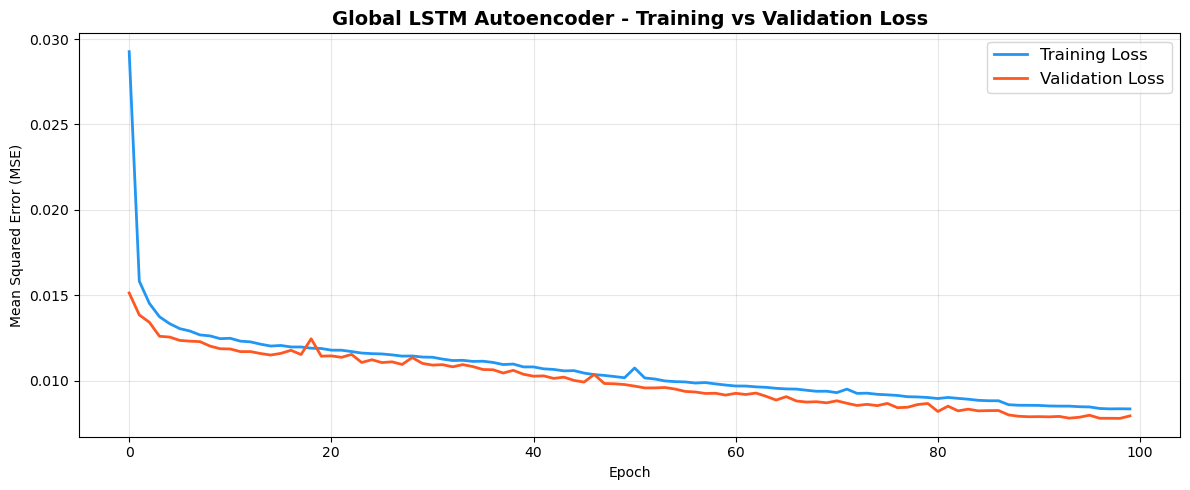

Final Training Loss: 0.008340
Final Validation Loss: 0.007929


In [35]:
# Plot Global Model Training Loss
plt.figure(figsize=(12, 5))
plt.plot(global_history.history['loss'], label='Training Loss', color='#2196F3', linewidth=2)
plt.plot(global_history.history['val_loss'], label='Validation Loss', color='#FF5722', linewidth=2)
plt.title('Global LSTM Autoencoder - Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('global_model_loss.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Training Loss: {global_history.history['loss'][-1]:.6f}")
print(f"Final Validation Loss: {global_history.history['val_loss'][-1]:.6f}")

## 7. Train Per-Cattle LSTM Autoencoder Models

In [ ]:
# Train individual models for each cattle
cattle_ids = df_normal['cattle_id'].unique()
per_cattle_histories = {}

for cid in cattle_ids:
    print(f"\n{'='*50}")
    print(f"Training Per-Cattle Model for: {cid}")
    
    cow_df = df_normal[df_normal['cattle_id'] == cid].copy()
    cow_scaled = scaler.transform(cow_df[FEATURES].values)
    cow_sequences = create_sequences(cow_scaled, SEQUENCE_LENGTH)
    
    print(f"  Sequences: {cow_sequences.shape}")
    
    cow_model = build_autoencoder(SEQUENCE_LENGTH, N_FEATURES)
    
    early_stop_cow = callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
    )
    reduce_lr_cow = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
    )
    
    history = cow_model.fit(
        cow_sequences, cow_sequences,
        epochs=60,
        batch_size=32,
        validation_split=0.1,
        shuffle=True,
        callbacks=[early_stop_cow, reduce_lr_cow],
        verbose=0
    )
    
    per_cattle_histories[cid] = history
    print(f"  Final Loss: {history.history['loss'][-1]:.6f}")
    print(f"  Final Val Loss: {history.history['val_loss'][-1]:.6f}")

print("\nAll Per-Cattle Models Trained!")


Training Per-Cattle Model for: COW_001
  Sequences: (4162, 30, 6)
  Final Loss: 0.011736
  Final Val Loss: 0.011711

Training Per-Cattle Model for: COW_002
  Sequences: (4162, 30, 6)


In [ ]:
# Plot Per-Cattle Training Losses
fig, axes = plt.subplots(1, len(cattle_ids), figsize=(6*len(cattle_ids), 5))
if len(cattle_ids) == 1:
    axes = [axes]

colors_cattle = ['#2196F3', '#4CAF50', '#FF9800']
for i, cid in enumerate(cattle_ids):
    h = per_cattle_histories[cid]
    axes[i].plot(h.history['loss'], label='Train Loss', color=colors_cattle[i%3], linewidth=2)
    axes[i].plot(h.history['val_loss'], label='Val Loss', color='#FF5722', linewidth=2, linestyle='--')
    axes[i].set_title(f'{cid} - Training Loss', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MSE')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Per-Cattle LSTM Autoencoder Training Losses', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('per_cattle_losses.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Reconstruction Error Analysis & Threshold Setting

In [ ]:
# Calculate reconstruction errors for Global Model
global_reconstructions = model.predict(all_sequences, verbose=0)
global_errors = np.mean(np.square(all_sequences - global_reconstructions), axis=(1, 2))

# Set threshold at 98th percentile (2% contamination)
CONTAMINATION = 0.02
global_threshold = float(np.percentile(global_errors, 100 * (1 - CONTAMINATION)))

print(f"Global Model Reconstruction Errors:")
print(f"  Mean Error: {np.mean(global_errors):.6f}")
print(f"  Std Error: {np.std(global_errors):.6f}")
print(f"  Min Error: {np.min(global_errors):.6f}")
print(f"  Max Error: {np.max(global_errors):.6f}")
print(f"  Threshold (98th percentile): {global_threshold:.6f}")

In [ ]:
# Plot reconstruction error distribution
plt.figure(figsize=(12, 5))
plt.hist(global_errors, bins=100, color='#2196F3', alpha=0.7, edgecolor='black', label='Reconstruction Errors')
plt.axvline(global_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {global_threshold:.4f}')
plt.title('Global Model - Reconstruction Error Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Frequency')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reconstruction_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Anomaly Detection Results

In [ ]:
# Test anomaly detection on full dataset including anomalies
df_all = df.copy()
df_all = df_all.dropna(subset=FEATURES)
df_all = df_all.sort_values(['cattle_id', 'timestamp']).reset_index(drop=True)

all_scaled = scaler.transform(df_all[FEATURES].values)
test_sequences = create_sequences(all_scaled, SEQUENCE_LENGTH)

# Predict
test_reconstructions = model.predict(test_sequences, verbose=0)
test_errors = np.mean(np.square(test_sequences - test_reconstructions), axis=(1, 2))

# Classify
predicted_anomalies = (test_errors > global_threshold).astype(int)

# Get actual labels (aligned with sequences)
actual_labels = df_all['is_anomaly'].values[SEQUENCE_LENGTH-1:]

print(f"Total test sequences: {len(test_sequences)}")
print(f"Predicted anomalies: {predicted_anomalies.sum()}")
print(f"Actual anomalies: {actual_labels.sum()}")
print(f"\nClassification Report:")
print(classification_report(actual_labels[:len(predicted_anomalies)], predicted_anomalies, target_names=['Normal', 'Anomaly']))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(actual_labels[:len(predicted_anomalies)], predicted_anomalies)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix - Global LSTM Autoencoder', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(actual_labels[:len(test_errors)], test_errors)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
plt.title('ROC Curve - LSTM Autoencoder Anomaly Detection', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

## 10. Model Comparison: Global vs Per-Cattle

In [ ]:
# Compare Global vs Per-Cattle reconstruction errors
comparison_results = []

for cid in cattle_ids:
    cow_df = df_normal[df_normal['cattle_id'] == cid]
    cow_scaled = scaler.transform(cow_df[FEATURES].values)
    cow_seqs = create_sequences(cow_scaled, SEQUENCE_LENGTH)
    
    # Global model errors on this cow
    global_recon = model.predict(cow_seqs, verbose=0)
    global_err = np.mean(np.square(cow_seqs - global_recon), axis=(1, 2))
    
    comparison_results.append({
        'Cattle ID': cid,
        'Global Model Mean Error': f"{np.mean(global_err):.6f}",
        'Global Model Std Error': f"{np.std(global_err):.6f}",
        'Sequences': len(cow_seqs)
    })

comparison_df = pd.DataFrame(comparison_results)
print("Model Comparison Results:")
print(comparison_df.to_string(index=False))

## 11. Save Models

In [ ]:
import joblib, os

os.makedirs('dl_service/models', exist_ok=True)

# Save Global Model
model.save('dl_service/models/global_model.h5')
print("Global model saved: dl_service/models/global_model.h5")

# Save threshold
joblib.dump(global_threshold, 'dl_service/models/global_threshold.joblib')
print(f"Global threshold saved: {global_threshold:.6f}")

# Save scaler
joblib.dump(scaler, 'dl_service/models/scalers.joblib')
print("Scaler saved: dl_service/models/scalers.joblib")

print("\nAll models saved successfully!")

## 12. Summary

| Model | Architecture | Training Data | Purpose |
|---|---|---|---|
| Global LSTM Autoencoder | LSTM(128)→LSTM(64)→RepeatVector→LSTM(64)→LSTM(128)→Dense | All cattle combined | Fallback for new cattle |
| Per-Cattle LSTM Autoencoder | Same architecture | Individual cattle | Fine-tuned per device |